# Valuation Toolkit — Walkthrough: Carnival Corporation (CCL)

This notebook runs the full toolkit end to end on a single real company:
a **DCF**, **trading comparables**, and **precedent transactions**
valuation, then a **credit overlay** that turns each method's Enterprise
Value into a leverage capacity and downside recovery view — the question a
direct lender or leveraged-finance analyst actually asks: *what can this
company support in debt, and what do you get back if it doesn't work out?*

Carnival was chosen specifically for the credit angle. It came out of
COVID with net leverage that peaked around **6.8x net debt/EBITDA at the
end of 2023**, and has spent the two years since deleveraging back toward
investment grade (~3.1–3.4x as of the most recent reporting, with Fitch
recognizing investment-grade leverage metrics). That means the credit
overlay's leverage sweep below (3x–6x) isn't an abstract stress range —
it brackets a real leverage path this specific company actually walked,
recently, with real outcomes at each point. See
[`LIMITATIONS.md`](../LIMITATIONS.md) in the repo root for every
simplification and open question behind this toolkit, stated explicitly.

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from data.fetch import build_company, cache_age
from valuation import utils, dcf, comps, precedent_transactions as pt, credit_overlay as co

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
TICKER = "CCL"
company = build_company(TICKER)
print(company)
print(f"Sector: {company.sector} | Currency: {company.currency} (financials in {company.financial_currency})")
print(f"Data cache age: {cache_age(TICKER)}  (None = freshly fetched this run)")

Company(ticker='CCL', name='CCL', sector='Consumer Cyclical')
Sector: Consumer Cyclical | Currency: USD (financials in USD)
Data cache age: 0:09:07.826540  (None = freshly fetched this run)


## 1. Company snapshot & historical unlevered free cash flow

Before projecting anything forward, build UFCF for the years already
reported — the same explicit EBIT → NOPAT → +D&A → −Capex → −ΔNWC waterfall
the DCF projection will reuse.

Three things stand out immediately in a cruise operator's financials that
wouldn't in, say, a software company's:

1. **2022 EBITDA and UFCF are negative** — Carnival's fiscal 2022 (ended
   Nov-2022) was still deep in COVID recovery, running well below
   pre-pandemic capacity utilization.
2. **Net working capital is structurally, deeply negative** (roughly
   −33% of revenue by 2025) — cruise passengers pay deposits and often
   full fare months before sailing, so advance ticket liabilities exceed
   receivables. This is a genuine cash-flow *tailwind* as the business
   grows, the opposite of most companies.
3. **The effective tax rate looks strange** — more on this below.

In [2]:
hist_ufcf = company.compute_historical_ufcf()
hist_ufcf

,revenue,ebit,tax_rate,nopat,d_and_a,capex,delta_nwc,ufcf
2022,"12,169,000,000.00","-4,471,000,000.00",0.21,"-3,532,090,000.00","2,275,000,000.00","4,940,000,000.00",NaN,NaN
2023,"21,593,000,000.00","2,004,000,000.00",0.21,"1,583,160,000.00","2,370,000,000.00","3,284,000,000.00","-3,102,000,000.00","3,771,160,000.00"
2024,"25,021,000,000.00","3,670,000,000.00",0.21,"2,899,300,000.00","2,557,000,000.00","4,626,000,000.00","-2,024,000,000.00","2,854,300,000.00"
2025,"26,621,000,000.00","4,121,000,000.00",0.00,"4,103,160,191.00","2,790,000,000.00","3,611,000,000.00","-634,000,000.00","3,916,160,191.00"


In [3]:
fin = company.financials.copy()
fin["ebitda_margin"] = fin["ebitda"] / fin["revenue"]
fin["nwc_pct_revenue"] = fin["nwc"] / fin["revenue"]
fin[["revenue", "ebitda", "ebitda_margin", "nwc", "nwc_pct_revenue", "tax_rate"]]

,revenue,ebitda,ebitda_margin,nwc,nwc_pct_revenue,tax_rate
2022,"12,169,000,000.00","-2,196,000,000.00",-0.18,"-3,113,000,000.00",-0.26,0.21
2023,"21,593,000,000.00","4,374,000,000.00",0.20,"-6,215,000,000.00",-0.29,0.21
2024,"25,021,000,000.00","6,227,000,000.00",0.25,"-8,239,000,000.00",-0.33,0.21
2025,"26,621,000,000.00","6,911,000,000.00",0.26,"-8,873,000,000.00",-0.33,0.00


**On that tax rate:** major cruise operators (Carnival is incorporated
under Panamanian law) qualify for the U.S. shipping-income tax exemption
under IRC §883, so their U.S.-taxable income on qualifying international
shipping activity is minimal — this is well documented in Carnival's own
10-K filings, not a data error. yfinance's 2025 figure (~0.4%) is much
closer to the real economic reality than the flat ~21% (the U.S.
statutory rate) it shows for 2022–2024, which looks like a default/
fallback value rather than Carnival's actual effective rate. The DCF below
overrides the forward tax-rate assumption manually for exactly this
reason — a concrete example of the toolkit's manual-override path solving
a real, not hypothetical, data-quality issue.

### Sanity-checking forward growth against history

In [4]:
first_year, last_year = company.financials.index[0], company.financials.index[-1]
revenue_cagr = utils.cagr(
    company.financials.loc[first_year, "revenue"],
    company.financials.loc[last_year, "revenue"],
    last_year - first_year,
)
print(f"Historical revenue CAGR ({first_year}-{last_year}): {revenue_cagr:.1%}  (COVID-recovery period -- not a useful forward run-rate)")
print(f"Year-over-year growth, most recent: {company.financials.loc[last_year, 'revenue'] / company.financials.loc[last_year - 1, 'revenue'] - 1:.1%}")
print("(Compare against the Year-1 forward growth assumption in Section 2 below -- the DCF assumes continued deceleration toward a mature run-rate, not a continuation of the recovery-era CAGR.)")

Historical revenue CAGR (2022-2025): 29.8%  (COVID-recovery period -- not a useful forward run-rate)
Year-over-year growth, most recent: 6.4%
(Compare against the Year-1 forward growth assumption in Section 2 below -- the DCF assumes continued deceleration toward a mature run-rate, not a continuation of the recovery-era CAGR.)


## 2. Discounted Cash Flow

Assumptions here are grounded in Carnival's own recent trend, not generic
defaults: revenue growth decelerating from the post-COVID recovery pace
toward a more mature ~5% run-rate, continued (but slowing) margin
expansion off the 2023→2025 trend (20.3% → 26.0%), and a manually
overridden low tax rate for the reason explained above.

**On beta:** left un-overridden here (auto-pulled from Yahoo Finance) to
show that code path — and it comes back unusually high (~2.3), reflecting
Carnival's COVID-era volatility still sitting inside whatever lookback
window Yahoo's undocumented methodology uses. A "normalized" cruise/
leisure-travel beta is more commonly cited in the 1.5–2.0 range. This is
left as the base case rather than smoothed away — it's a real, disclosed
input, and it's exactly the kind of number an analyst should sanity-check
rather than blindly trust, not something this toolkit should quietly
correct on your behalf.

In [5]:
assumptions = {
    "years": 5,
    "revenue_growth": [0.07, 0.065, 0.06, 0.055, 0.05],   # decelerating from recovery-era pace toward a mature run-rate
    "ebitda_margin":  [0.27, 0.275, 0.28, 0.285, 0.29],    # continued, slowing margin expansion off the 2023-2025 trend
    "da_pct_revenue": 0.105,    # matches recent (~10-11%) actuals
    "capex_pct_revenue": 0.14,  # normalized newbuild cadence, between 2024's 18.5% and 2025's 13.6%
    "nwc_pct_revenue": -0.335,  # structurally negative -- advance ticket deposits, a real funding source
    "tax_rate": 0.02,           # manual override: IRC Section 883 shipping-income exemption (see Section 1)
}

projection = dcf.project_ufcf(company, assumptions)
projection

,revenue,ebitda,d_and_a,ebit,tax_rate,nopat,capex,nwc,delta_nwc,ufcf
2026,"28,484,470,000.00","7,690,806,900.00","2,990,869,350.00","4,699,937,550.00",0.02,"4,605,938,799.00","3,987,825,800.00","-9,542,297,450.00","-669,297,450.00","4,278,279,799.00"
2027,"30,335,960,550.00","8,342,389,151.25","3,185,275,857.75","5,157,113,293.50",0.02,"5,053,971,027.63","4,247,034,477.00","-10,162,546,784.25","-620,249,334.25","4,612,461,742.63"
2028,"32,156,118,183.00","9,003,713,091.24","3,376,392,409.21","5,627,320,682.03",0.02,"5,514,774,268.38","4,501,856,545.62","-10,772,299,591.31","-609,752,807.06","4,999,062,939.03"
2029,"33,924,704,683.06","9,668,540,834.67","3,562,093,991.72","6,106,446,842.95",0.02,"5,984,317,906.09","4,749,458,655.63","-11,364,776,068.83","-592,476,477.52","5,389,429,719.71"
2030,"35,620,939,917.22","10,330,072,575.99","3,740,198,691.31","6,589,873,884.69",0.02,"6,458,076,406.99","4,986,931,588.41","-11,933,014,872.27","-568,238,803.44","5,779,582,313.33"


In [6]:
wacc_inputs = {
    "risk_free_rate": 0.04,          # ~US 10-year Treasury yield
    "equity_risk_premium": 0.05,     # long-run US equity risk premium
    "cost_of_debt_pre_tax": 0.065,   # reflects a still-improving-but-not-fully-investment-grade credit profile
    "tax_rate": 0.02,                # same manual override as the DCF projection (IRC Sec. 883), for consistency --
                                      # left as a default, compute_wacc would otherwise fall back to CCL's raw
                                      # fetched 2025 tax rate (0.4%), which is a different number for the same
                                      # underlying real-world reason and would silently misstate the debt tax shield
    # beta intentionally omitted -- auto-pulled from Yahoo Finance via data/fetch.py
}
wacc_breakdown = dcf.compute_wacc(company, **wacc_inputs)
pd.Series(wacc_breakdown, name="WACC build-up").to_frame()

,WACC build-up
risk_free_rate,0.04
beta,2.34
equity_risk_premium,0.05
cost_of_equity,0.16
cost_of_debt_pre_tax,0.07
tax_rate,0.02
cost_of_debt_after_tax,0.06
market_value_equity,"31,816,949,034.37"
market_value_debt,"24,712,000,000.00"
equity_weight,0.56


In [7]:
result = dcf.run_dcf(
    company,
    assumptions,
    wacc_inputs,
    terminal_growth_rate=0.025,  # conservative for a mature, capital-intensive, cyclical business
    exit_multiple=10.0,          # between CCL's own current ~8x and premium peers RCL/VIK -- see Section 3
)
result.summary()

,Gordon Growth,Exit Multiple
Terminal value (undiscounted),"64,987,562,285.83","103,300,725,759.93"
PV of terminal value,"37,514,899,782.16","59,631,662,398.16"
PV of explicit-period UFCF,"17,939,382,380.38","17,939,382,380.38"
Enterprise Value,"55,454,282,162.54","77,571,044,778.54"
Equity Value,"30,742,282,162.54","52,859,044,778.54"
Implied Share Price,22.45,38.59
TV as % of EV,0.68,0.77


### Sensitivity: WACC × Terminal Growth Rate

In [8]:
wacc_range = [wacc_breakdown["wacc"] + d for d in (-0.015, -0.0075, 0.0, 0.0075, 0.015)]
growth_range = [0.015, 0.02, 0.025, 0.03, 0.035]

grid = dcf.sensitivity_grid(company, projection, wacc_range, growth_range, method="gordon", metric="implied_share_price")
grid

Terminal Growth Rate,1.50%,2.00%,2.50%,3.00%,3.50%
WACC,,,,,
10.12%,26.29,28.35,30.67,33.32,36.36
10.87%,22.62,24.30,26.19,28.31,30.72
11.62%,19.50,20.89,22.45,24.18,26.12
12.37%,16.81,17.98,19.28,20.71,22.30
13.12%,14.47,15.46,16.56,17.76,19.08


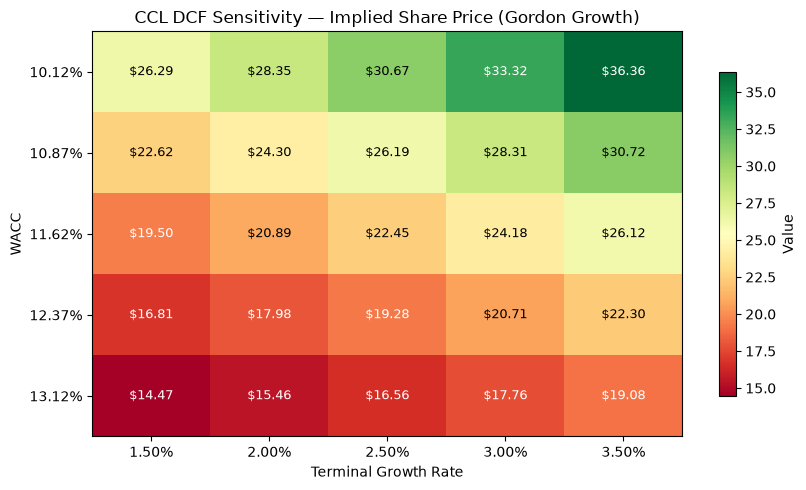

In [9]:
fig = dcf.plot_sensitivity_heatmap(grid, title=f"{TICKER} DCF Sensitivity — Implied Share Price (Gordon Growth)")
plt.show()

## 3. Trading Comparables

The pure-play global ocean cruise peer set is small by construction —
Carnival, Royal Caribbean, and Norwegian together represent the large
majority of global ocean cruise capacity — plus Viking Holdings, the
2024 IPO covering river/expedition cruising.

In [10]:
candidate_tickers = ["RCL", "NCLH", "VIK"]
peers = comps.select_peers(candidate_tickers, target_sector=company.sector, market_cap_range=(1e9, 1e13))
peers

,ticker,sector,market_cap
0,RCL,Consumer Cyclical,"71,062,018,718.80"
1,NCLH,Consumer Cyclical,"7,085,268,463.78"
2,VIK,Consumer Cyclical,"27,113,261,010.00"


In [11]:
peer_multiples = comps.fetch_peer_multiples(peers["ticker"].tolist())
peer_multiples

,ev_ebitda,ev_revenue,pe
ticker,,,
RCL,12.93,5.11,16.42
NCLH,8.44,2.19,9.35
VIK,16.15,4.46,28.25


Note the spread: NCLH trades at a discount (8.4x EV/EBITDA, still working
through its own deleveraging), Viking at a premium (16.2x, a newly-public
"growth" story), and Royal Caribbean in between-to-rich (12.9x, the
industry's least-levered, highest-quality credit). For reference, CCL's
own current EV/EBITDA (market EV over reported EBITDA) works out to
roughly **8.2x** — closer to NCLH than to RCL, consistent with the market
still pricing in Carnival's higher (if rapidly improving) leverage. The
DCF's 10.0x exit multiple assumption above sits between CCL's own current
multiple and the peer group's median, reflecting a modest re-rating as the
deleveraging story continues — not an assumption that CCL suddenly trades
like Royal Caribbean.

In [12]:
peer_stats = comps.summarize_peer_multiples(peer_multiples)
peer_stats

C:\Users\Irmak\AppData\Local\Temp\ipykernel_15936\1298549740.py:1: UserWarning: summarize_peer_multiples: only 3 peer(s) have a usable 'ev_ebitda' multiple -- quartile stats from this small a sample are noisy.
  peer_stats = comps.summarize_peer_multiples(peer_multiples)
C:\Users\Irmak\AppData\Local\Temp\ipykernel_15936\1298549740.py:1: UserWarning: summarize_peer_multiples: only 3 peer(s) have a usable 'ev_revenue' multiple -- quartile stats from this small a sample are noisy.
  peer_stats = comps.summarize_peer_multiples(peer_multiples)
C:\Users\Irmak\AppData\Local\Temp\ipykernel_15936\1298549740.py:1: UserWarning: summarize_peer_multiples: only 3 peer(s) have a usable 'pe' multiple -- quartile stats from this small a sample are noisy.
  peer_stats = comps.summarize_peer_multiples(peer_multiples)


,ev_ebitda,ev_revenue,pe
mean,12.51,3.92,18.01
median,12.93,4.46,16.42
q1,10.69,3.32,12.89
q3,14.54,4.78,22.34
min,8.44,2.19,9.35
max,16.15,5.11,28.25
count,3.00,3.00,3.00


In [13]:
comps_valuation = comps.comps_valuation(company, peer_stats)
comps_valuation

,metric,stat,multiple,implied_ev,implied_equity_value,implied_share_price
0,ev_ebitda,q1,10.69,"73,853,464,827.65","49,141,464,827.65",35.88
1,ev_ebitda,median,12.93,"89,358,087,161.60","64,646,087,161.60",47.20
2,ev_ebitda,q3,14.54,"100,491,765,098.02","75,779,765,098.02",55.33
3,ev_ebitda,mean,12.51,"86,444,124,229.91","61,732,124,229.91",45.07
4,ev_revenue,q1,3.32,"88,400,221,026.78","63,688,221,026.78",46.50
5,ev_revenue,median,4.46,"118,611,174,375.66","93,899,174,375.66",68.56
6,ev_revenue,q3,4.78,"127,277,175,241.61","102,565,175,241.61",74.88
7,ev_revenue,mean,3.92,"104,247,872,720.38","79,535,872,720.38",58.07


## 4. Precedent Transactions

Large-scale cruise-sector M&A is genuinely rare — again, because CCL, RCL,
and NCLH essentially *are* the industry at scale, so there are few
plausible acquirers or targets left to transact with each other. This
dataset has **two** real, sourced cruise-sector deals (vs. six for
enterprise software in the same curated CSV) — treat the "quartile" stats
below as two real data points, not a robust distribution; the toolkit's
own small-sample warning will fire on this.

In [14]:
transactions = pt.load_precedent_transactions()
cruise_transactions = pt.filter_transactions(transactions, sector="Cruise & Leisure Travel")
cruise_transactions[["announcement_date", "acquirer", "target", "ev_ebitda"]]

,announcement_date,acquirer,target,ev_ebitda
0,2014-09-02,Norwegian Cruise Line Holdings,Prestige Cruises International (Oceania Cruise...,12.20
1,2018-06-14,Royal Caribbean Cruises,Silversea Cruises (66.7% stake acquired; EV on...,14.00


In [15]:
txn_stats = pt.summarize_transaction_multiples(cruise_transactions)
precedent_valuation = pt.precedent_valuation(company, txn_stats)
precedent_valuation

C:\Users\Irmak\AppData\Local\Temp\ipykernel_15936\2452798118.py:1: UserWarning: summarize_transaction_multiples: only 2 deal(s) have a usable 'ev_ebitda' multiple -- quartile stats from this small a sample are noisy.
  txn_stats = pt.summarize_transaction_multiples(cruise_transactions)


,metric,stat,multiple,implied_ev,implied_equity_value,implied_share_price
0,ev_ebitda,q1,12.65,"87,424,150,000.00","62,712,150,000.00",45.79
1,ev_ebitda,median,13.10,"90,534,100,000.00","65,822,100,000.00",48.06
2,ev_ebitda,q3,13.55,"93,644,050,000.00","68,932,050,000.00",50.33
3,ev_ebitda,mean,13.10,"90,534,100,000.00","65,822,100,000.00",48.06


In [16]:
premium = pt.control_premium(txn_stats, peer_stats)
print(f"Precedent-transaction median EV/EBITDA vs. today's trading-comps median: {premium:+.1%}")

Precedent-transaction median EV/EBITDA vs. today's trading-comps median: +1.3%


### Football Field: DCF vs. Comps vs. Precedent Transactions

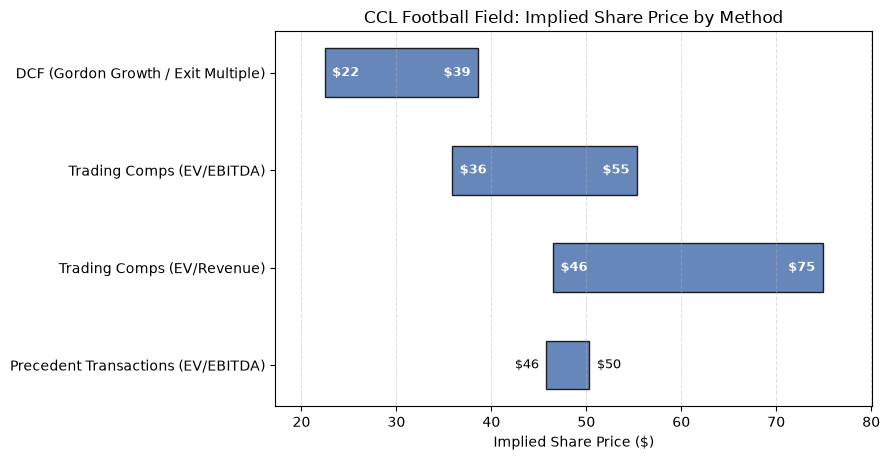

For reference, CCL's actual current share price: $23.23


In [17]:
ranges = {
    "DCF (Gordon Growth / Exit Multiple)": (
        min(result.implied_share_price_gordon, result.implied_share_price_exit),
        max(result.implied_share_price_gordon, result.implied_share_price_exit),
    ),
    "Trading Comps (EV/EBITDA)": comps.implied_share_price_range(comps_valuation, "ev_ebitda"),
    "Trading Comps (EV/Revenue)": comps.implied_share_price_range(comps_valuation, "ev_revenue"),
    "Precedent Transactions (EV/EBITDA)": comps.implied_share_price_range(precedent_valuation, "ev_ebitda"),
}
fig = comps.plot_football_field(ranges, title=f"{TICKER} Football Field: Implied Share Price by Method")
plt.show()
print(f"For reference, {TICKER}'s actual current share price: ${company.share_price:,.2f}")

## 5. Credit Overlay — the differentiator

Every method above answers "what is this company worth?" This section
takes that Enterprise Value and asks what a direct lender actually asks:
at various leverage levels, what's the debt quantum, is interest coverage
adequate, how much equity cushion sits below the debt — and in a downside,
what does each leverage tranche actually recover?

**This is where Carnival's real history matters.** Net debt/EBITDA peaked
around **6.8x at the end of 2023** and has been paid down to roughly
**3.1x–3.4x** as of the most recent reporting (Fitch has since recognized
investment-grade leverage metrics). The 3x–6x sweep below isn't a
hypothetical stress range — it brackets where this specific company
actually sat, recently, at both ends. We'll use the DCF Exit Multiple EV
as the base case, since exit multiples are the more directly comparable
convention to how a leverage lender itself thinks about EV.

Stress assumptions are also set for this sector specifically, not reused
from a generic default: cruise demand is highly discretionary and
fuel-cost-sensitive, and COVID demonstrated EBITDA can go outright
negative in a tail scenario — a 30% EBITDA decline with 20% multiple
compression is a meaningfully more severe (and more sector-appropriate)
stress case than would apply to a lower-cyclicality business.

In [18]:
base_ev = result.ev_exit
current_leverage = company.net_debt / company.latest("ebitda")
print(f"Enterprise Value used for credit overlay (DCF, Exit Multiple): ${base_ev:,.0f}")
print(f"CCL's current net debt / EBITDA (this toolkit's own EBITDA figure): {current_leverage:.1f}x")
print("(Carnival's own 'adjusted EBITDA' basis puts this closer to ~3.1x-3.4x as of the most recent reporting --")
print(" the gap versus our GAAP-based EBITDA is the same 'which EBITDA' lesson as the Micro Focus precedent-transaction footnote.)")

leverage = co.leverage_analysis(
    company,
    base_ev,
    leverage_levels=(3.0, 4.0, 5.0, 6.0),
    interest_rate=[0.06, 0.07, 0.08, 0.10],  # wider spread priced in at higher leverage
)
leverage

Enterprise Value used for credit overlay (DCF, Exit Multiple): $77,571,044,779
CCL's current net debt / EBITDA (this toolkit's own EBITDA figure): 3.6x
(Carnival's own 'adjusted EBITDA' basis puts this closer to ~3.1x-3.4x as of the most recent reporting --
 the gap versus our GAAP-based EBITDA is the same 'which EBITDA' lesson as the Micro Focus precedent-transaction footnote.)


,ebitda,debt_quantum,interest_rate,interest_expense,interest_coverage,enterprise_value,equity_cushion,equity_cushion_pct_of_ev,below_2.0x_covenant,below_2.5x_covenant
leverage_x,,,,,,,,,,
3.00,"6,911,000,000.00","20,733,000,000.00",0.06,"1,243,980,000.00",5.56,"77,571,044,778.54","56,838,044,778.54",0.73,False,False
4.00,"6,911,000,000.00","27,644,000,000.00",0.07,"1,935,080,000.00",3.57,"77,571,044,778.54","49,927,044,778.54",0.64,False,False
5.00,"6,911,000,000.00","34,555,000,000.00",0.08,"2,764,400,000.00",2.50,"77,571,044,778.54","43,016,044,778.54",0.55,False,False
6.00,"6,911,000,000.00","41,466,000,000.00",0.10,"4,146,600,000.00",1.67,"77,571,044,778.54","36,105,044,778.54",0.47,True,True


In [19]:
downside = co.downside_recovery(
    company,
    leverage_levels=(3.0, 4.0, 5.0, 6.0),
    ebitda_decline=0.30,          # more severe than a generic default -- cruise demand is highly discretionary
    exit_multiple=10.0,           # same base-case multiple as the DCF, for consistency
    multiple_compression=0.20,    # travel-sector multiples compress more than a typical business under stress
)
downside

,debt_quantum,base_ebitda,stressed_ebitda,exit_multiple,stressed_multiple,stressed_ev,recovery_value,recovery_pct,equity_value_in_stress,equity_wiped_out
leverage_x,,,,,,,,,,
3.00,"20,733,000,000.00","6,911,000,000.00","4,837,700,000.00",10.00,8.00,"38,701,600,000.00","20,733,000,000.00",1.00,"17,968,600,000.00",False
4.00,"27,644,000,000.00","6,911,000,000.00","4,837,700,000.00",10.00,8.00,"38,701,600,000.00","27,644,000,000.00",1.00,"11,057,600,000.00",False
5.00,"34,555,000,000.00","6,911,000,000.00","4,837,700,000.00",10.00,8.00,"38,701,600,000.00","34,555,000,000.00",1.00,"4,146,600,000.00",False
6.00,"41,466,000,000.00","6,911,000,000.00","4,837,700,000.00",10.00,8.00,"38,701,600,000.00","38,701,600,000.00",0.93,0.00,True


In [20]:
credit_summary = co.credit_summary_table(leverage, downside)
credit_summary

,debt_quantum,interest_coverage,equity_cushion_pct_of_ev,recovery_pct,equity_wiped_out,below_2.0x_covenant,below_2.5x_covenant
leverage_x,,,,,,,
3.00,"20,733,000,000.00",5.56,0.73,1.00,False,False,False
4.00,"27,644,000,000.00",3.57,0.64,1.00,False,False,False
5.00,"34,555,000,000.00",2.50,0.55,1.00,False,False,False
6.00,"41,466,000,000.00",1.67,0.47,0.93,True,True,True


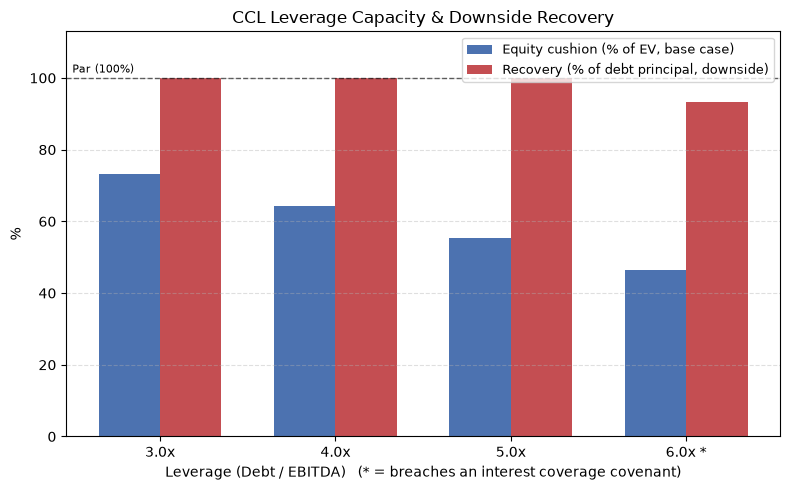

In [21]:
fig = co.plot_leverage_recovery(credit_summary, title=f"{TICKER} Leverage Capacity & Downside Recovery")
plt.show()

**As a sanity check**, this exact `credit_overlay` code was first developed
and tested against Microsoft: even at 6x leverage combined with a 25%
EBITDA decline and 15% multiple compression, MSFT's recovery stayed at a
flat 100% — its Enterprise Value is simply too large relative to any
plausible debt quantum for recovery risk to ever bind; interest coverage
constrained leverage well before recovery did. Carnival, above, is the
other kind of company: real leverage, real cyclicality, a real recent
history of actually operating at both ends of this leverage range — the
chart above should show meaningfully more separation between the base
case and the downside than MSFT's flat line did.

## Synthesis

**Equity perspective:** the four ranges span roughly $22 (DCF Gordon
Growth, the most conservative method) to $75 (trading comps' EV/Revenue
high end) — CCL's actual current share price ($23.23) sits almost exactly
at the DCF's *low* end and well below every other method's low end. That's
a meaningfully different picture from a "fairly valued, tight range"
story: either the DCF's assumptions are too conservative, or the market
is pricing in something the other methods don't capture directly — and
given Section 5 below, "still-elevated leverage and execution risk on the
deleveraging path" is a plausible candidate, not just a generic hedge.
The precedent-transaction range ($46–$50) and trading-comps EV/EBITDA
range ($36–$55) cluster closer together than either does to the DCF,
and the control premium came out modestly *positive* this time (+1.3%,
unlike the MSFT walkthrough's -5.7%) — with peer and deal multiples both
sitting in a tight band around 12-13x, this pairing didn't hit the
vintage-mismatch problem documented in `LIMITATIONS.md`.

**Credit perspective:** at CCL's actual current leverage (~3.6x on this
toolkit's own EBITDA figure, ~3.1–3.4x on Carnival's own adjusted basis —
both sit almost exactly on the 3x tranche modeled above), interest
coverage is a comfortable 5.56x and a severe downside (30% EBITDA decline,
20% multiple compression) still leaves lenders fully whole. At 6x — close
to where Carnival actually sat at the end of 2023 — the picture is
genuinely different, not a flat continuation: interest coverage collapses
to 1.67x, breaching both the 2.0x and 2.5x covenant thresholds, and the
same downside stress leaves only 93% recovery with **equity fully wiped
out**. That's the real differentiator this notebook was built to show:
run the identical `credit_overlay` code on a company with real, recent
leverage history instead of a mega-cap with a permanently oversized
equity cushion, and the leverage/recovery chart actually moves — which is
exactly what happened, and exactly why Carnival replaced Microsoft as
this walkthrough's subject.